In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load the dataset
df = pd.read_csv('credit_risk_dataset.csv')

# 2. Handle Missing Values 
# Instead of inplace=True, we assign the result directly back to the column
df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median())
df['loan_int_rate'] = df['loan_int_rate'].fillna(df['loan_int_rate'].median())
# 3. Clean Outliers
# Sometimes data has errors (e.g., person_age = 144). Let's keep it realistic for Zimbabwe.
df = df[df['person_age'] < 100]
df = df[df['person_emp_length'] < 60] # No one works for 60 years!

# 4. Feature Engineering: The "Risk Ratio"
# Banks look at how much of a person's income goes to the loan.
df['loan_to_income_ratio'] = df['loan_amnt'] / df['person_income']

print("Data Cleaning Complete. Current Shape:", df.shape)
df.head()

Data Cleaning Complete. Current Shape: (32574, 13)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_to_income_ratio
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2,0.104167
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3,0.572917
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2,0.534351
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4,0.643382
5,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2,0.252525


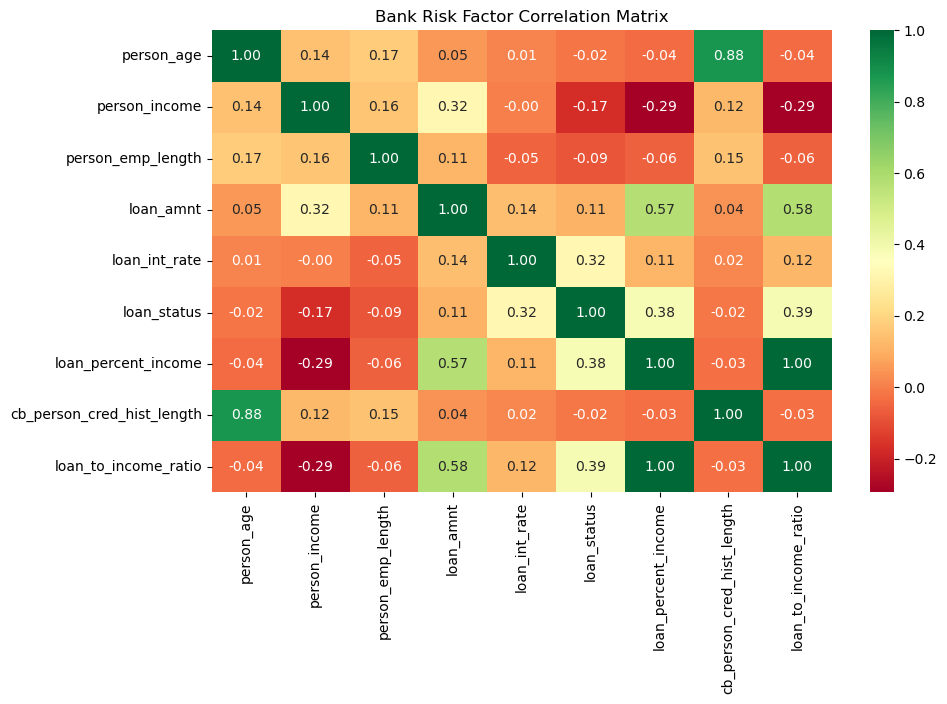

In [14]:
plt.figure(figsize=(10,6))

# Add numeric_only=True inside the corr() function
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='RdYlGn', fmt='.2f')

plt.title('Bank Risk Factor Correlation Matrix')
plt.show()

In [16]:
# 1. Identify which columns are text (categorical)
# These are usually: 'person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file'

# 2.  One-Hot Encoding to turn words into 1s and 0s
df_encoded = pd.get_dummies(df, columns=['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file'])

# 3.  the new columns
print("New columns created:", df_encoded.columns[-5:]) # Look at the last 5 columns
df_encoded.head()

New columns created: Index(['loan_grade_E', 'loan_grade_F', 'loan_grade_G',
       'cb_person_default_on_file_N', 'cb_person_default_on_file_Y'],
      dtype='object')


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,loan_to_income_ratio,person_home_ownership_MORTGAGE,...,loan_intent_VENTURE,loan_grade_A,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_N,cb_person_default_on_file_Y
1,21,9600,5.0,1000,11.14,0,0.10,2,0.104167,False,...,False,False,True,False,False,False,False,False,True,False
2,25,9600,1.0,5500,12.87,1,0.57,3,0.572917,True,...,False,False,False,True,False,False,False,False,True,False
3,23,65500,4.0,35000,15.23,1,0.53,2,0.534351,False,...,False,False,False,True,False,False,False,False,True,False
4,24,54400,8.0,35000,14.27,1,0.55,4,0.643382,False,...,False,False,False,True,False,False,False,False,False,True
5,21,9900,2.0,2500,7.14,1,0.25,2,0.252525,False,...,True,True,False,False,False,False,False,False,True,False


In [18]:
from sklearn.model_selection import train_test_split

# 1. Define 'X' (Features) and 'y' (Target)
# y is what we want to predict (loan_status)
y = df_encoded['loan_status']
# X is everything EXCEPT the target
X = df_encoded.drop('loan_status', axis=1)

# 2. Performing the Split (80% for training, 20% for testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} rows")
print(f"Testing set size: {X_test.shape[0]} rows")

Training set size: 26059 rows
Testing set size: 6515 rows


In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Initialize the Model
# n_estimators=100 means we are using 100 "Decision Trees" to vote
model = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. The Training Phase 
# We feed it the features (X_train) and the answers (y_train)
model.fit(X_train, y_train)

# 3. The Prediction Phase 
# We ask the model to predict outcomes for the data it hasn't seen yet
y_pred = model.predict(X_test)

print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      5099
           1       0.97      0.73      0.83      1416

    accuracy                           0.94      6515
   macro avg       0.95      0.86      0.90      6515
weighted avg       0.94      0.94      0.93      6515



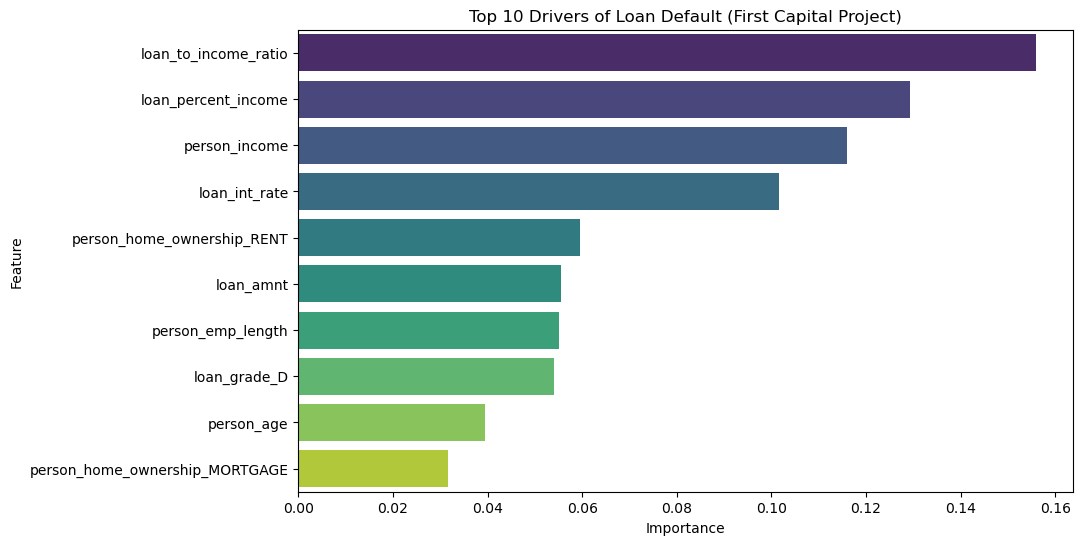

In [25]:
import matplotlib.pyplot as plt

# 1. Get the importance scores from the model
importances = model.feature_importances_
feature_names = X.columns

# 2. Sorting
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).head(10)

# 3. Plot the Top 10 Features (Future-Proof Version)
plt.figure(figsize=(10,6))
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=feature_importance_df, 
    hue='Feature', 
    palette='viridis', 
    legend=False
)

plt.title('Top 10 Drivers of Loan Default (First Capital Project)')
plt.show()

In [29]:
# 1. Creating an 'Applicant' Profile
# We need to match the exact columns our model was trained on (X_train)
sample_data = X_test.iloc[0:1].copy() # We'll start by "borrowing" one row's structure

# 2.customizing this person's stats
sample_data['person_income'] = 45000       # Annual Income in USD
sample_data['loan_amnt'] = 15000           # Wanting to borrow $15k
sample_data['loan_int_rate'] = 11.0        # Interest rate
sample_data['person_age'] = 24             # A young professional
sample_data['loan_to_income_ratio'] = 0.33 # They are spending 33% of income on this loan

# 3. Ask the AI for the Verdict
prediction = model.predict(sample_data)
probability = model.predict_proba(sample_data)

# 4. Print the Result
if prediction[0] == 0:
    print(f"LOAN APPROVED: The model is {probability[0][0]*100:.1f}% confident this user will pay.")
else:
    print(f" LOAN REJECTED: The model is {probability[0][1]*100:.1f}% confident this user will default.")

 LOAN REJECTED: The model is 60.0% confident this user will default.


In [33]:
import joblib

# This 'dumps' the trained model into a permanent file
joblib.dump(model, 'loan_model.pkl')

# We also need to save the list of columns so our "App" knows the order
joblib.dump(X.columns, 'model_columns.pkl')

print("Model saved successfully! You now have a portable AI.")

Model saved successfully! You now have a portable AI.


In [35]:
import joblib

# 'X' is the variable we created during the Train-Test split
# It contains all our features (Income, Age, etc.)
joblib.dump(X.columns, 'model_columns.pkl')

print("Column map saved!")

Column map saved!
